In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax 
import jax.numpy as jnp

import jax._src.linear_util as lu
import jax.api_util as api_util

import matplotlib.pyplot as plt

from probjax.utils.jaxutils import flatten_fun
import scipy

jax.config.update("jax_platform_name", "cpu")

In [3]:
x = jax.random.normal(jax.random.PRNGKey(0), (1000, 2))
y = jax.random.normal(jax.random.PRNGKey(0), (1000, 2)) * 0.01

In [4]:
xs = jnp.concatenate([x, y], axis=0)

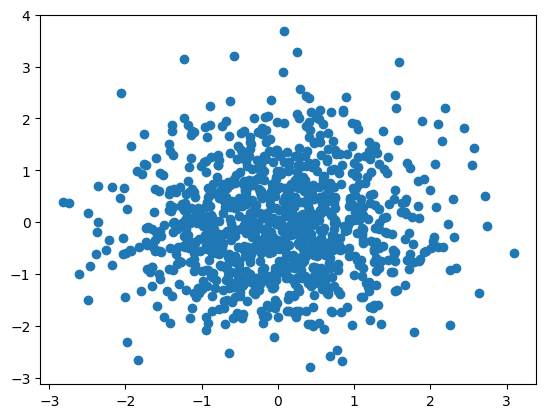

In [5]:
plt.scatter(xs[:, 0], xs[:, 1])

In [6]:
def log_potential(x, z):
    x_mean = z**2
    return jnp.sum(-0.5 * (x_mean - x) ** 2 + -0.5*z**2)


In [7]:
from probjax.inference.mcmc import MCMC
from probjax.inference.kernels import HMC

## Simple 1D example

Here we run a **single** MCMC chain on a multi-modal 1D distribution. 

In [8]:
init_x = jax.random.normal(jax.random.PRNGKey(0), (1,))
x_obs = jnp.array([[4.]])
key = jax.random.PRNGKey(0)


log_density_fn = lambda z: log_potential(x_obs, z)

### HMCKernel

In [9]:
kernel = HMC(log_density_fn)
state = kernel.init(init_x)
params = kernel.init_params(init_x, step_size=0.2)

In [10]:
state, info = kernel(jax.random.PRNGKey(3), state, params)

In [11]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 10_000, params=params, thin=50)

(array([0.0037867 , 0.0037867 , 0.00568005, 0.02461346, 0.04354709,
        0.08141412, 0.172295  , 0.23288225, 0.31240302, 0.44493562,
        0.49037807, 0.6418462 , 0.66077972, 0.71758027, 0.80088774,
        0.70811191, 0.77437907, 0.63616615, 0.63616615, 0.4695512 ,
        0.48091023, 0.31429637, 0.27453599, 0.25749524, 0.22530884,
        0.14010802, 0.09845428, 0.10224076, 0.05301385, 0.04165374,
        0.02461352, 0.01514681, 0.00946676, 0.00946674, 0.00757341,
        0.00757341, 0.00189335, 0.0037867 , 0.00568005, 0.00189335,
        0.00189335, 0.        , 0.00189335, 0.00189335, 0.        ,
        0.        , 0.00189335, 0.00189334, 0.00189335, 0.        ,
        0.00189335, 0.00189335, 0.00189335, 0.        , 0.        ,
        0.0037867 , 0.00189335, 0.        , 0.        , 0.        ,
        0.00378669, 0.00568005, 0.0037867 , 0.00757341, 0.01325346,
        0.0037867 , 0.00568005, 0.02272012, 0.02082687, 0.03976038,
        0.03976038, 0.0549072 , 0.07762742, 0.10

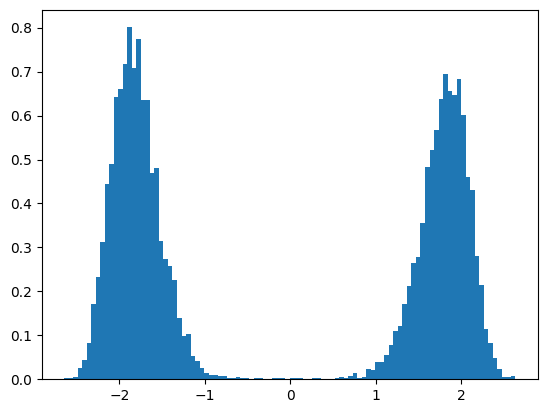

In [12]:
plt.hist(samples.flatten(), bins=100, density=True) 

### NUTSKernel

In [14]:
kernel = nuts(log_density_fn, step_size=0.1)
state = kernel.init_state(init_x)

NameError: name 'NUTSKernel' is not defined

In [13]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=10)

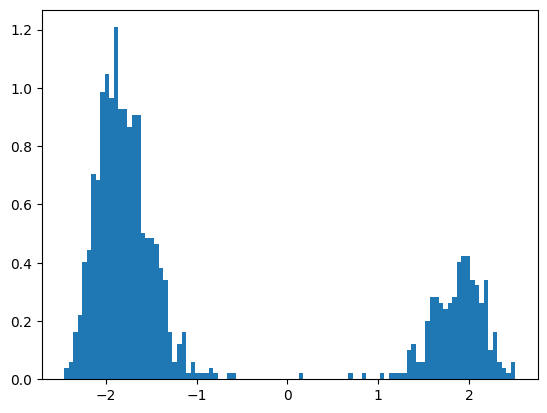

In [14]:
_ = plt.hist(samples.flatten(), bins=100, density=True)

### Dynamic HMC

In [15]:
kernel = DynamicHMCKernel(log_density_fn, step_size=0.1, average_integration_steps=20)
state = kernel.init_state(init_x)

In [16]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=10)

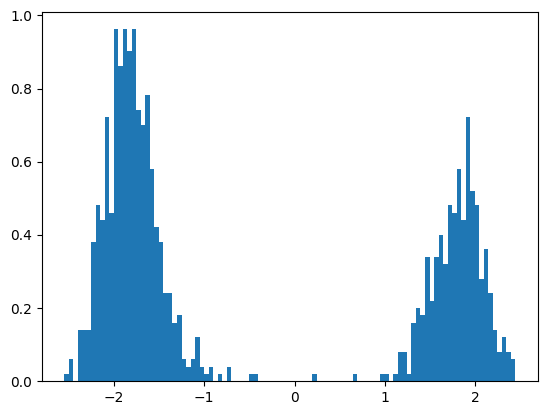

In [17]:
_ = plt.hist(samples.flatten(), bins=100, density=True)

## Langevian 

In [18]:
kernel = MALAKernel(log_density_fn, step_size=1e-2)
state = kernel.init_state(init_x)

In [19]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=10)

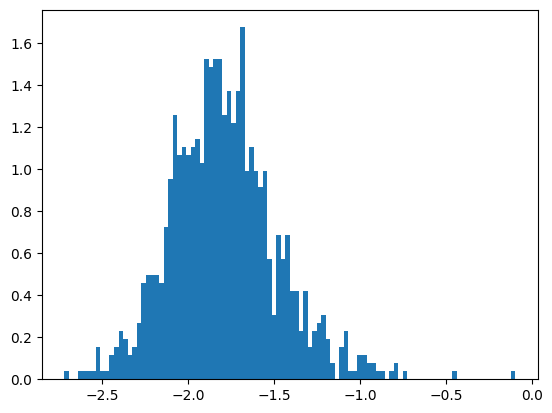

In [20]:
_ = plt.hist(samples.flatten(), bins=100, density=True)

### Metropolis Hasting

In [21]:
kernel = GaussianMHKernel(log_density_fn, 1.)
state = kernel.init_state(init_x)

In [22]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=10)

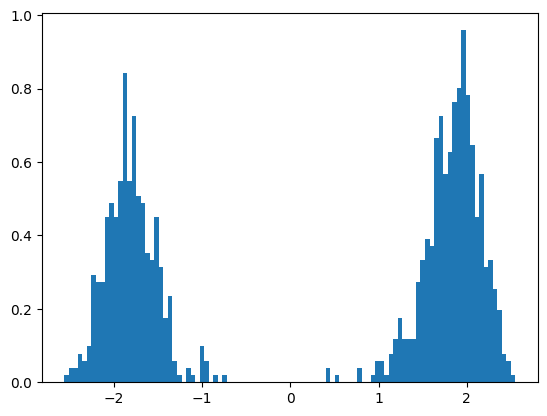

In [23]:
_ = plt.hist(samples.flatten(), bins=100, density=True)

### Independent Metropolis Hasting

In [24]:
kernel = GaussianIMHKernel(log_density_fn, 0., 2.)
state = kernel.init_state(init_x)

In [25]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=10)

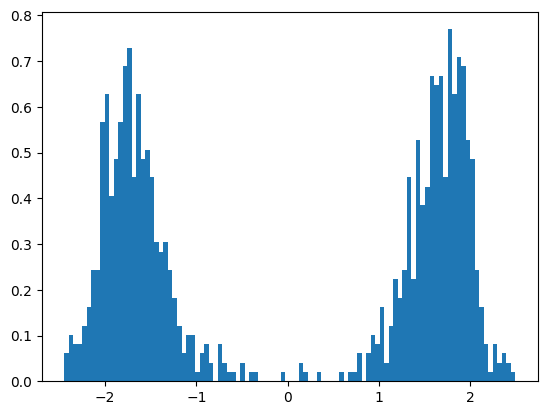

In [26]:
_ = plt.hist(samples.flatten(), bins=100, density=True)

### Elliptical Slice Sampling

In [27]:
kernel = EllipticalSliceKernel(log_density_fn, jnp.eye(1), jnp.zeros(1))    
state = kernel.init_state(init_x)

In [28]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=10)

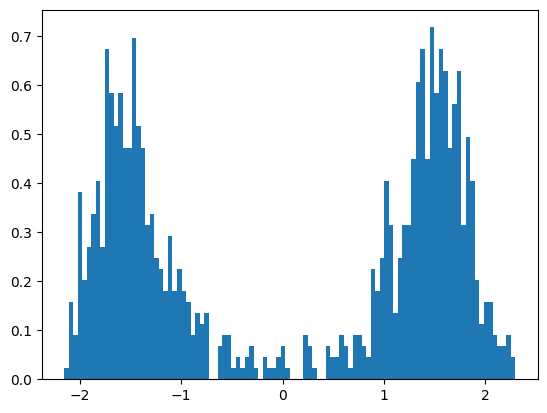

In [29]:
_ = plt.hist(samples.flatten(), bins=100, density=True)

# Slice

In [79]:
from probjax.inference.kernels.slice import SliceKernel

kernel = SliceKernel(log_density_fn, slice_fn="none")
state = kernel.init_state(init_x, jax.random.PRNGKey(0))

In [31]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=10)

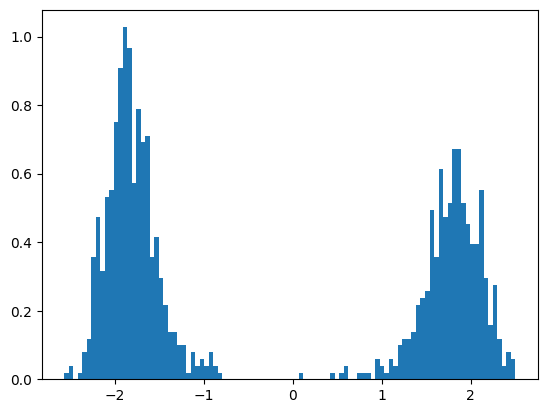

In [32]:
_ = plt.hist(samples.flatten(), bins=100, density=True)

In [84]:
def stochastic_logdensity():
    global key
    key = jax.random.PRNGKey(0)
    
    def log_density_fn_est(x):
        global key 
        key, subkey = jax.random.split(key,2)
        return log_density_fn(x) + jax.random.normal(subkey)*0.1
    
    return log_density_fn_est
    
log_density_est = stochastic_logdensity()

In [85]:
kernel = SliceKernel(log_density_est)
state = kernel.init_state(init_x, rng_key=jax.random.PRNGKey(0))

In [86]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=100)

UnexpectedTracerError: Encountered an unexpected tracer. A function transformed by JAX had a side effect, allowing for a reference to an intermediate value with type uint32[2] wrapped in a DynamicJaxprTracer to escape the scope of the transformation.
JAX transformations require that functions explicitly return their outputs, and disallow saving intermediate values to global state.
The function being traced when the value leaked was body_fn at /mnt/c/Users/manug/OneDrive/Uni/PHD/probjax/probjax/inference/kernels/slice.py:196 traced for while_loop.
------------------------------
The leaked intermediate value was created on line /tmp/ipykernel_4676/2545433105.py:7 (log_density_fn_est). 
------------------------------
When the value was created, the final 5 stack frames (most recent last) excluding JAX-internal frames were:
------------------------------
/mnt/c/Users/manug/OneDrive/Uni/PHD/probjax/probjax/inference/kernels/slice.py:61 (__call__)
/mnt/c/Users/manug/OneDrive/Uni/PHD/probjax/

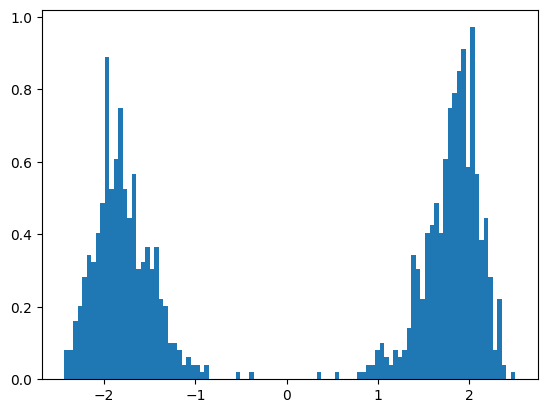

In [71]:
_ = plt.hist(samples.flatten(), bins=100, density=True)

# 2d Examples

In [33]:
x_obs = jnp.array([4.,4.])
log_density_fn = lambda z: log_potential(x_obs, z)
init_x = jax.random.normal(key, (2,))

# HMC

In [34]:
kernel = HMCKernel(log_density_fn, step_size=0.1)
state = kernel.init_state(init_x)

In [35]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=10)

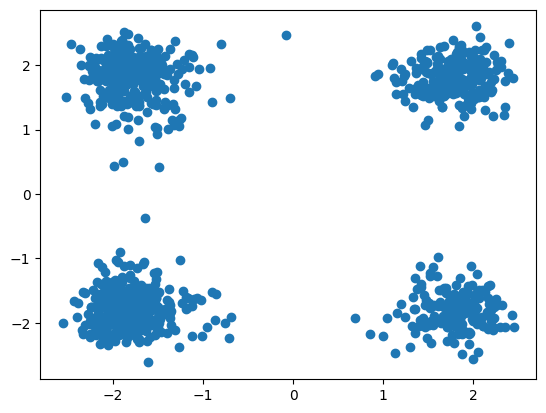

In [36]:
plt.scatter(samples[:,0], samples[:,1])

# NUTS

In [37]:
kernel = NUTSKernel(log_density_fn, step_size=0.1)
state = kernel.init_state(init_x)

In [38]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=10)

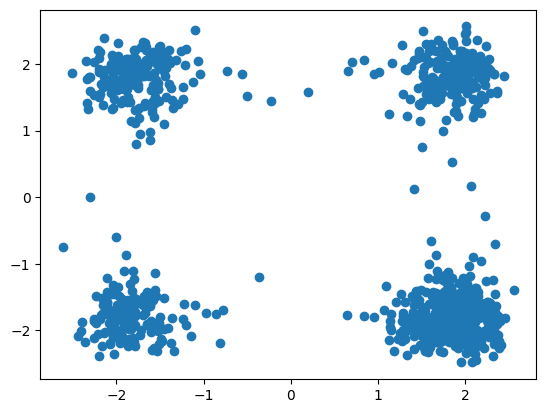

In [39]:
plt.scatter(samples[:,0], samples[:,1])

## Dynamic HMC

In [40]:
kernel = DynamicHMCKernel(log_density_fn, step_size=0.1, average_integration_steps=20)
state = kernel.init_state(init_x)

In [41]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=10)

(-3.0, 3.0)

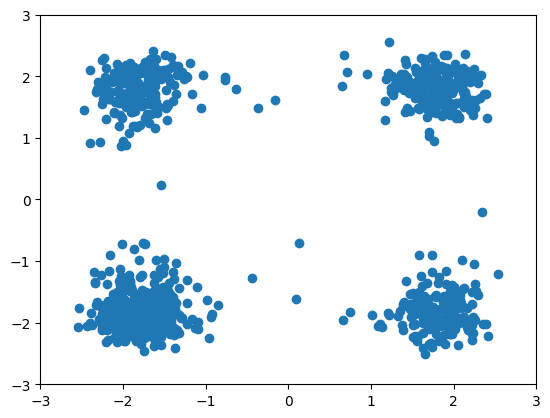

In [43]:
plt.scatter(samples[:,0], samples[:,1])
plt.xlim(-3,3)
plt.ylim(-3,3)

# Langevin

In [44]:
kernel = MALAKernel(log_density_fn, step_size=1e-2)
state = kernel.init_state(init_x)

In [45]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=20)

(-3.0, 3.0)

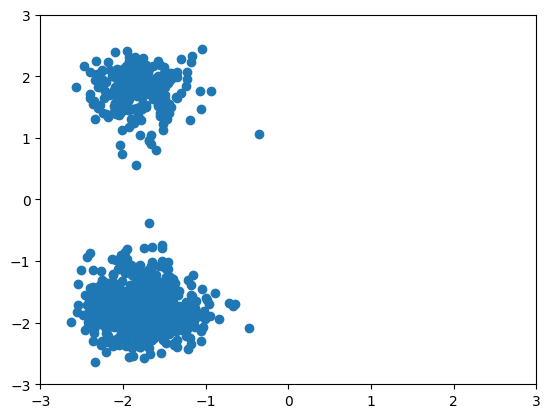

In [46]:
plt.scatter(samples[:,0], samples[:,1])
plt.xlim(-3,3)
plt.ylim(-3,3)

# Metropolis

In [47]:
kernel = GaussianMHKernel(log_density_fn, 1.)
state = kernel.init_state(init_x)

In [48]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=20)

(-3.0, 3.0)

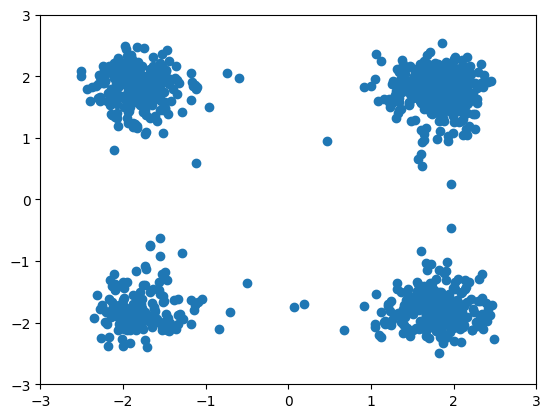

In [49]:
plt.scatter(samples[:,0], samples[:,1])
plt.xlim(-3,3)
plt.ylim(-3,3)

# Independent metropolis

In [50]:
kernel = GaussianIMHKernel(log_density_fn, 0., 2.)
state = kernel.init_state(init_x)

In [51]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=20)

(-3.0, 3.0)

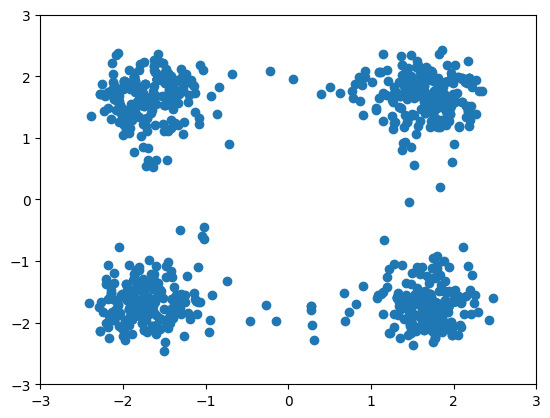

In [52]:
plt.scatter(samples[:,0], samples[:,1])
plt.xlim(-3,3)
plt.ylim(-3,3)

# Elliptical slice

In [53]:
kernel = EllipticalSliceKernel(log_density_fn, jnp.eye(2), jnp.zeros(2))    
state = kernel.init_state(init_x)

In [54]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=20)

(-3.0, 3.0)

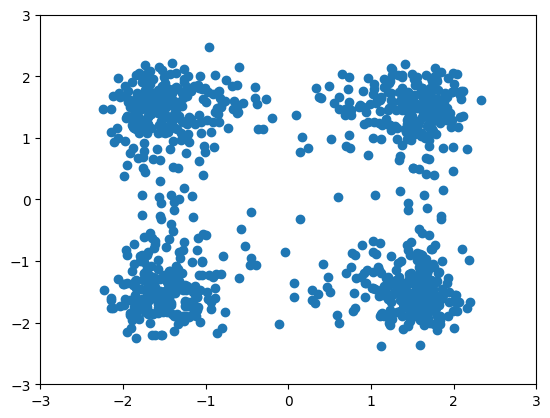

In [55]:
plt.scatter(samples[:,0], samples[:,1])
plt.xlim(-3,3)
plt.ylim(-3,3)

## Slice


In [56]:
from probjax.inference.kernels.slice import SliceKernel

kernel = SliceKernel(log_density_fn, slice_fn="poly")
state = kernel.init_state(init_x, jax.random.PRNGKey(0))

In [57]:
mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thin=10)

(-3.0, 3.0)

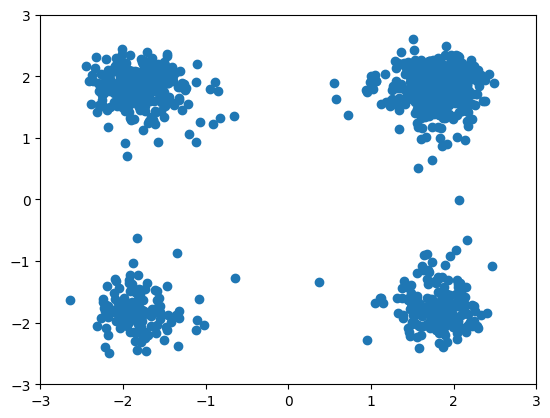

In [58]:
plt.scatter(samples[:,0], samples[:,1])
plt.xlim(-3,3)
plt.ylim(-3,3)

# Gibbs

In [90]:
from probjax.inference.kernels import gibbs 
import blackjax

def log_potential(x, y):
    return jnp.sum(-0.5 * (x - y) ** 2)

kernel1 = blackjax.mala
kernel2 = blackjax.mala
kernels =  {"x": kernel1, "y": kernel2}
inner_kernel_kwarg = {"x": {"step_size": 1e-2}, "y": {"step_size": 1e-2}}
inner_kernel_steps = {"x": 1, "y": 10}


sampler = gibbs(log_potential, kernels, inner_kernel_kwargs=inner_kernel_kwarg, inner_kernel_steps=inner_kernel_steps)
position = {"x": jnp.array([0.]), "y": jnp.array([0.])}

In [91]:
state = sampler.init(position)

In [99]:
sampler.step(jax.random.PRNGKey(0), state)

Traced<ShapedArray(uint32[2])>with<DynamicJaxprTrace(level=1/0)>


(GibbsState(position={'x': Array([0.22121528], dtype=float32), 'y': Array([0.46715066], dtype=float32)}, inner_state={'x': MALAState(position=Array([0.22121528], dtype=float32), logdensity=Array(-0.0244681, dtype=float32), logdensity_grad=Array([-0.22121528], dtype=float32)), 'y': MALAState(position=Array([0.46715066], dtype=float32), logdensity=Array(-0.10911487, dtype=float32), logdensity_grad=Array([-0.46715066], dtype=float32))}),
 GibbsInfo(inner_info={'x': MALAInfo(acceptance_rate=Array(1., dtype=float32), is_accepted=Array(True, dtype=bool)), 'y': MALAInfo(acceptance_rate=Array(0.99988484, dtype=float32), is_accepted=Array(True, dtype=bool))}))

mcmc = MCMC(kernel, verbose=True)
samples, final_state = mcmc.sample(key,state, 1000, thinning=10)

In [2]:
import blackjax 
import jax
import jax.numpy as jnp

key = jax.random.PRNGKey(0)

def log_density(x):
    return -0.5 * jnp.sum(x ** 2/jnp.array([1., 2., 3., 4., 5., 6., 7., 8., 9., 10.]))

adaption_state, info = blackjax.pathfinder_adaptation(blackjax.hmc, log_density, num_integration_steps=5,initial_step_size=1.,adaptation_info_fn=lambda state, info, adapt_state: info.acceptance_rate).run(key, jnp.array([1.]*10), 100)

2024-10-13 20:59:43.955848: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [7]:
blackjax.hmc.build_kernel()

<function blackjax.mcmc.hmc.build_kernel.<locals>.kernel(rng_key: jax.Array, state: blackjax.mcmc.hmc.HMCState, logdensity_fn: Callable, step_size: float, inverse_mass_matrix: Union[blackjax.mcmc.metrics.Metric, jax.Array, Callable[[Union[jax.Array, numpy.ndarray, numpy.bool, numpy.number, bool, int, float, complex, Iterable[ForwardRef('ArrayLikeTree')], Mapping[Any, ForwardRef('ArrayLikeTree')]]], jax.Array]], num_integration_steps: int) -> tuple[blackjax.mcmc.hmc.HMCState, blackjax.mcmc.hmc.HMCInfo]>

In [8]:
?blackjax.hmc.init

Signature:
blackjax.hmc.init(
    position: Union[jax.Array, numpy.ndarray, numpy.bool, numpy.number, bool, int, float, complex, Iterable[ForwardRef('ArrayLikeTree')], Mapping[Any, ForwardRef('ArrayLikeTree')]],
    logdensity_fn: Callable,
)
Docstring: <no docstring>
File:      ~/miniconda3/envs/probjax_new/lib/python3.12/site-packages/blackjax/mcmc/hmc.py
Type:      function

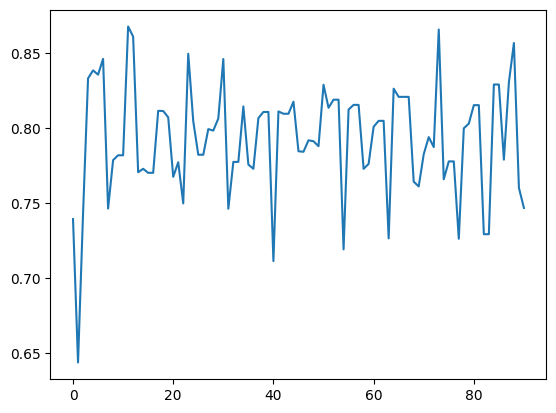

In [9]:
import matplotlib.pyplot as plt

# Window average of acceptance rate
window_size = 10
window_avg = jnp.convolve(info, jnp.ones(window_size), mode="valid") / window_size

plt.plot(window_avg)

In [7]:
import blackjax
from blackjax.mcmc.dynamic_hmc import halton_trajectory_length
from blackjax.vi.svgd import rbf_kernel
import optax
state  =blackjax.dynamic_hmc.init(init_x, log_density_fn, jax.random.PRNGKey(0))

kernel = blackjax.dynamic_hmc.build_kernel()

NameError: name 'init_x' is not defined

In [10]:
blackjax.irmh.build_kernel()

<function blackjax.mcmc.random_walk.build_irmh.<locals>.kernel(rng_key: jax.Array, state: blackjax.mcmc.random_walk.RWState, logdensity_fn: Callable, proposal_distribution: Callable, proposal_logdensity_fn: Optional[Callable] = None) -> tuple[blackjax.mcmc.random_walk.RWState, blackjax.mcmc.random_walk.RWInfo]>

In [30]:
%reload_ext autoreload
%autoreload 2


In [31]:
from probjax.inference.kernels.hmc import HMC, NUTS
from probjax.inference.kernels.imh import GaussianIMH
from probjax.inference.kernels.mh import GaussRWMH
from probjax.inference.kernels.mala import MALA
from probjax.inference.kernels.elliptical_slice import EllipticalSlice
from probjax.inference.kernels.slice import Slice
from probjax.inference.kernels.latent_slice import LatentSlice
from probjax.inference.kernels.dynamic_hmc import dHMC


import jax.numpy as jnp
import jax

key = jax.random.PRNGKey(0)

sigma = 1.
def logdensity_fn(x):
    return -0.5 * jnp.sum(x ** 2/(2*sigma**2))

kernel = dHMC(logdensity_fn)

In [32]:
state  = kernel.init(jnp.array([0.]), random_generator_arg=jnp.array(0))
params  = kernel.init_params(jnp.array([1.]))

In [33]:
state,info = kernel(key+1, state, params)

state,info

(DynamicHMCState(position=Array([0.00638753], dtype=float32), logdensity=Array(-1.0200129e-05, dtype=float32), logdensity_grad=Array([-0.00319376], dtype=float32), random_generator_arg=Array(1, dtype=int32)),
 HMCInfo(momentum=Array([-0.01108583], dtype=float32), acceptance_rate=Array(0.9999997, dtype=float32), is_accepted=Array(True, dtype=bool), is_divergent=Array(False, dtype=bool), energy=Array(6.1766565e-05, dtype=float32), proposal=IntegratorState(position=Array([0.00638753], dtype=float32), momentum=Array([-0.01015544], dtype=float32), logdensity=Array(-1.0200129e-05, dtype=float32), logdensity_grad=Array([-0.00319376], dtype=float32)), num_integration_steps=Array(10, dtype=int32)))

In [25]:
import blackjax
blackjax.dynamic_hmc.build_kernel

<function blackjax.mcmc.dynamic_hmc.build_kernel(integrator: Callable = <function generate_euclidean_integrator.<locals>.euclidean_integrator at 0x7f7048accae0>, divergence_threshold: float = 1000, next_random_arg_fn: Callable = <function <lambda> at 0x7f7048b0ca40>, integration_steps_fn: Callable = <function <lambda> at 0x7f7048b0cae0>)>

In [34]:
_, params = kernel.adapt_params(key, state.position, params, 1000)
params

TypeError: build_kernel.<locals>.kernel() missing 1 required positional argument: 'num_integration_steps'

In [17]:
import blackjax
?blackjax.window_adaptation

Signature:
blackjax.window_adaptation(
    algorithm,
    logdensity_fn: Callable,
    is_mass_matrix_diagonal: bool = True,
    initial_step_size: float = 1.0,
    target_acceptance_rate: float = 0.8,
    progress_bar: bool = False,
    adaptation_info_fn: Callable = <function return_all_adapt_info at 0x7f7048b0d120>,
    integrator=<function generate_euclidean_integrator.<locals>.euclidean_integrator at 0x7f7048accae0>,
    **extra_parameters,
) -> blackjax.base.AdaptationAlgorithm
Docstring:
Adapt the value of the inverse mass matrix and step size parameters of
algorithms in the HMC fmaily. See Blackjax.hmc_family

Algorithms in the HMC family on a euclidean manifold depend on the value of
at least two parameters: the step size, related to the trajectory
integrator, and the mass matrix, linked to the euclidean metric.

Good tuning is very important, especially for algorithms like NUTS which can
be extremely inefficient with the wrong parameter values. This function
provides a genera

In [19]:
?blackjax.pathfinder_adaptation

Signature:
blackjax.pathfinder_adaptation(
    algorithm,
    logdensity_fn: Callable,
    initial_step_size: float = 1.0,
    target_acceptance_rate: float = 0.8,
    adaptation_info_fn: Callable = <function return_all_adapt_info at 0x7f7048b0d120>,
    **extra_parameters,
) -> blackjax.base.AdaptationAlgorithm
Docstring:
Adapt the value of the inverse mass matrix and step size parameters of
algorithms in the HMC fmaily.

Parameters
----------
algorithm
    The algorithm whose parameters are being tuned.
logdensity_fn
    The log density probability density function from which we wish to sample.
initial_step_size
    The initial step size used in the algorithm.
target_acceptance_rate
    The acceptance rate that we target during step size adaptation.
adaptation_info_fn
    Function to select the adaptation info returned. See return_all_adapt_info
    and get_filter_adapt_info_fn in blackjax.adaptation.base.  By default all
    information is saved - this can result in excessive memory

In [6]:
kernel(key, state, params)

(HMCState(position=Array([0.19459143], dtype=float32), logdensity=Array(-0.01893291, dtype=float32), logdensity_grad=Array([-0.19459143], dtype=float32)),
 HMCInfo(momentum=Array([0.14389051], dtype=float32), acceptance_rate=Array(1., dtype=float32), is_accepted=Array(True, dtype=bool), is_divergent=Array(False, dtype=bool), energy=Array(0.48028553, dtype=float32), proposal=IntegratorState(position=Array([0.19459143], dtype=float32), momentum=Array([-0.96057546], dtype=float32), logdensity=Array(-0.01893291, dtype=float32), logdensity_grad=Array([-0.19459143], dtype=float32)), num_integration_steps=10))

In [10]:
def f(x, **params):
    print(params)
    return x ** 2

f(2., *params)

TypeError: f() takes 1 positional argument but 4 were given

In [13]:
def f(x,y):
    return x + y
from functools import partial
_f = partial(f, x=1)
_f(y=1, x=2)

3

In [8]:
import blackjax
import jax


blackjax.window_adaptation(HMC, logdensity_fn, num_integration_steps=5).run(jax.random.PRNGKey(0), jnp.array([1.]), 100)

(AdaptationResults(state=HMCState(position=Array([0.91141397], dtype=float32), logdensity=Array(-0.4153377, dtype=float32), logdensity_grad=Array([-0.91141397], dtype=float32)), parameters={'step_size': Array(0.88427806, dtype=float32, weak_type=True), 'inverse_mass_matrix': Array([0.77814466], dtype=float32), 'num_integration_steps': 5}),
 AdaptationInfo(state=HMCState(position=Array([[-0.10946679],
        [-0.10946679],
        [-0.10946679],
        [-0.6430122 ],
        [ 2.1371799 ],
        [-2.6531649 ],
        [ 2.6628447 ],
        [ 1.2617278 ],
        [ 1.2617278 ],
        [ 1.5078489 ],
        [ 0.1760796 ],
        [-0.5150595 ],
        [ 0.2335388 ],
        [-0.10530257],
        [-0.10530257],
        [ 1.9272597 ],
        [-2.1281033 ],
        [ 0.1825707 ],
        [-0.38702834],
        [-0.38702834],
        [-0.26210573],
        [-0.10870712],
        [-0.10870712],
        [-0.64797616],
        [ 0.4939373 ],
        [ 0.4939373 ],
        [-1.1217538 ]

In [60]:
from probjax.inference.kernels.slice import slice

state = slice.init(init_x, log_density_fn, jax.random.PRNGKey(0))
kernel = slice.build_kernel()

In [61]:
kernel(jax.random.PRNGKey(0), state, log_density_fn)

(SliceState(position=Array([-1.6605978 ,  0.88576365], dtype=float32), log_density=Array(-7.71235, dtype=float32), random_arg_slice=Array([2467461003,  428148500], dtype=uint32)),
 SliceInfo(num_evals=Array(5, dtype=int32, weak_type=True), proposal=SliceState(position=Array([-0.78476596,  0.85644484], dtype=float32), log_density=Array(-11.735907, dtype=float32), random_arg_slice=Array([0, 0], dtype=uint32))))

In [28]:
state = blackjax.svgd.init(jax.random.normal(key,(500,)), kernel_parameters={"length_scale": 0.1}, optimizer=optax.adam(1e-2))

In [29]:
kernel = blackjax.svgd.build_kernel(optax.adam(1e-2))

In [30]:
state = kernel(state, jax.grad(log_density_fn), kernel=rbf_kernel)

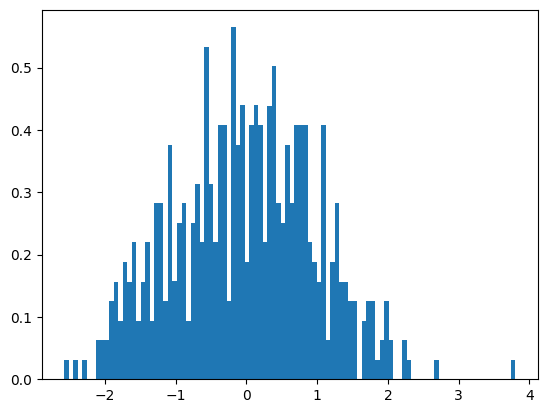

In [31]:
_ = plt.hist(state.particles.flatten(), bins=100, density=True)

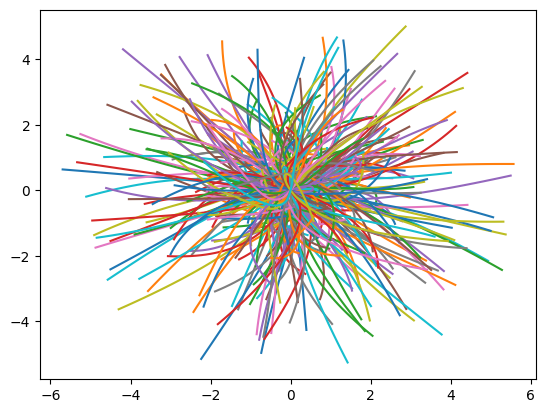

In [46]:
pos = jnp.zeros((2,))


def polynomial_path(t, key, degree=3):
    
    degrees = jnp.arange(1,degree+ 1)
    # Factorial of degrees
    factorial = jnp.cumprod(degrees)
    # Powers of t
    t_powers = jnp.power(t, degrees)
    # Coefficients
    a = jax.random.normal(key, (degree,2))
    a = a / jnp.linalg.norm(a, axis=-1, keepdims=True)
    # Factors
    factors = 1. / factorial * t_powers
    return pos + jnp.sum(a * factors[:, None], axis=0)
    

def log_potential(x):
    return -jnp.sum((x - jnp.array([1., 1.]))**2)

# Plot polynomial path in 2D
t = jnp.linspace(-2, 2, 100)
keys = jax.random.split(key, 200)
path1 = jax.vmap(jax.vmap(lambda x,k: polynomial_path(x,k, degree=5),in_axes=(0, None)),in_axes=(None,0))(t, keys)
plt.plot(path1[:, :,0].T, path1[:, :,1].T, label="Polynomial path")
plt.scatter(*pos, color="red", label="Initial position")


In [32]:
from probjax.inference.rejection.univariate import build_slice_kernel, init

ImportError: cannot import name 'build_slice_kernel' from 'probjax.inference.univariate' (/mnt/c/Users/manug/OneDrive/Uni/PHD/probjax/probjax/inference/univariate.py)

In [ ]:
state = init(init_x, jax.random.PRNGKey(0))

In [ ]:
kernel = build_slice_kernel()

In [ ]:
kernel(jax.random.PRNGKey(0),state, log_density_fn, max_steps=1000, step_size=1.)

False


(SliceState(position=Array([-0.9584873], dtype=float32), random_arg_slice=Array([2467461003,  428148500], dtype=uint32)),
 SliceInfo(num_evals=Array(5, dtype=int32, weak_type=True), proposal=SliceState(position=Array([-0.20584226], dtype=float32), random_arg_slice=Array([0, 0], dtype=uint32))))

In [ ]:
jnp.sign(jnp.array([1., 2., -3.]))

Array([ 1.,  1., -1.], dtype=float32)

In [ ]:
jax.vmap(halton_trajectory_length, in_axes=(0,None))(jnp.arange(0, 100), 10)

Array([10,  5, 15,  3, 12,  8, 17,  2, 11,  6, 16,  4, 14,  9, 18,  1, 11,
        6, 15,  3, 13,  8, 18,  2, 12,  7, 17,  5, 14,  9, 19,  1, 10,  6,
       15,  3, 13,  8, 17,  2, 11,  7, 16,  4, 14,  9, 19,  1, 11,  6, 16,
        4, 13,  9, 18,  3, 12,  7, 17,  5, 14, 10, 19,  1, 10,  5, 15,  3,
       13,  8, 17,  2, 11,  7, 16,  4, 14,  9, 18,  1, 11,  6, 15,  4, 13,
        8, 18,  2, 12,  7, 17,  5, 14, 10, 19,  1, 10,  6, 15,  3],      dtype=int32)

In [ ]:
state  =blackjax.dynamic_hmc.init(init_x, log_density_fn, jnp.zeros(1), 

kernel = blackjax.dynamic_hmc.build_kernel()

SyntaxError: incomplete input (3625956712.py, line 3)

In [ ]:
kernel(key, state, log_density_fn, 1e-2, jnp.eye(1))

(DynamicHMCState(position=Array([-0.2021625], dtype=float32), logdensity=Array(-7.857791, dtype=float32), logdensity_grad=Array([-1.3986129], dtype=float32), random_generator_arg=Array([2718843009, 1272950319], dtype=uint32)),
 HMCInfo(momentum=Array([0.14389051], dtype=float32), acceptance_rate=Array(1., dtype=float32), is_accepted=Array(True, dtype=bool), is_divergent=Array(False, dtype=bool), energy=Array(7.86295, dtype=float32), proposal=IntegratorState(position=Array([-0.2021625], dtype=float32), momentum=Array([-0.1015785], dtype=float32), logdensity=Array(-7.857791, dtype=float32), logdensity_grad=Array([-1.3986129], dtype=float32)), num_integration_steps=Array(3, dtype=int32)))

In [ ]:
kernel(key, ess, log_density_fn)

(EllipSliceState(position=Array([-1.1243103], dtype=float32), logdensity=Array(-4.374684, dtype=float32)),
 EllipSliceInfo(momentum=Array([0.17348514], dtype=float32), theta=Array(5.047429, dtype=float32), subiter=Array(1, dtype=int32, weak_type=True)))

In [ ]:
import blackjax


nuts = blackjax.hmc()

# Initialize the state
initial_position = {"loc": 1., "scale": 2.}
state = nuts.init(initial_position)

# Iterate
rng_key = jax.random.key(0)
for _ in range(100):
    rng_key, nuts_key = jax.random.split(rng_key)
    state, _ = nuts.step(nuts_key, state)

TypeError: hmc.__new__() missing 4 required positional arguments: 'logdensity_fn', 'step_size', 'inverse_mass_matrix', and 'num_integration_steps'

In [ ]:
from jax._src.flatten_util import ravel_pytree
from jax._src import linear_util as lu

In [ ]:
x = {"x": jnp.ones((100,1)), "y": jnp.ones((100,1))}
y = jnp.ones((100,1))*0.2

In [ ]:
def f(x, y):
    return (x["x"] + x["y"]) * y

In [ ]:
from jax._src.api_util import flatten_fun as flatten_fun_
from jax._src.api_util import flatten_fun_nokwargs as flatten_fun_nokwargs_
from jax._src.api_util import flatten_axes

In [ ]:
def ravel_pytree_by_axis(tree, axis = -1):
    leaves, treedef = jax.tree_util.tree_flatten(tree)
    shapes = jax.tree_util.tree_map(lambda x: x.shape, leaves)
    # Check if all shapes are the same, except the specified axis can be different
    shape_without_axis = shapes[0][:axis] + shapes[0][axis+1:]
    assert all(tuple(shape[:axis] + shape[axis+1:]) == shape_without_axis for shape in shapes[1:]), "All dimensions must be the same except the specified axis"
    
    axis_sizes = jax.tree_util.tree_map(lambda x: x.shape[axis], leaves)

    def unravel_array(array):
        split = jnp.split(array, axis_sizes, axis=axis)
        return jax.tree_util.tree_unflatten(treedef, split)
        
    
    return jnp.concatenate(leaves, axis=axis), unravel_array

In [ ]:
def ravel_first_arg(f, unravel):
  return ravel_first_arg_(lu.wrap_init(f), unravel).call_wrapped

def ravel_args(f, unravel):
  return ravel_args_(lu.wrap_init(f), unravel).call_wrapped

def flatten_args(f, in_tree):
  return flatten_args_(lu.wrap_init(f), in_tree).call_wrapped

def flatten_fun(f, in_tree):
  f_flat, out_tree = flatten_fun_(lu.wrap_init(f), in_tree)
  return f_flat.call_wrapped, out_tree
  

@lu.transformation
def ravel_first_arg_(unravel, y_flat, *args):
    y = unravel(y_flat)
    ans = yield (y,) + args, {}
    ans_flat, _ = ravel_pytree(ans)
    yield ans_flat
   
@lu.transformation 
def ravel_args_(unravel, args_flat):
    args = unravel(args_flat)
    ans = yield args, {}
    ans_flat, _ = ravel_pytree(ans)
    yield ans_flat
    

@lu.transformation
def flatten_args_(in_tree, args):
    args = jax.tree_util.tree_unflatten(in_tree, tuple(args))
    ans = yield args, {}
    ans_flat, _ = jax.tree_util.tree_flatten(ans)
    yield ans_flat
  

In [ ]:
flat_x, unravel = ravel_pytree(x)
f_flat = ravel_first_arg(f, unravel)
f_flat(flat_x, y)

Array([0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,
       0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4], dtype=float32)

In [ ]:
flat_x, unravel = ravel_pytree((x,y))
f_flat2 = ravel_args(f, unravel)

In [ ]:
flat_x, in_tree = jax.tree_util.tree_flatten(x)
f_flat3, out_tree = flatten_fun(f, in_tree)

In [ ]:
f_flat3(*flat_x)

TypeError: dict() argument after ** must be a mapping, not str

In [ ]:
flat_args, intree = jax.tree_util.tree_flatten((x,y))
f_warp = lu.wrap_init(f)
f_flat, out_tree = flatten_fun_nokwargs_(f_warp, intree)
out = f_flat.call_wrapped(*flat_args)
output = jax.tree_unflatten(out_tree(), out)

/tmp/ipykernel_26526/2722155376.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree_util.tree_unflatten.
  output = jax.tree_unflatten(out_tree(), out)


In [ ]:
flatten_axes("test", in_tree, jax.tree_unflatten(in_tree, (0,0,0)))

/tmp/ipykernel_26526/158589325.py:1: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree_util.tree_unflatten.
  flatten_axes("test", in_tree, jax.tree_unflatten(in_tree, (0,0,0)))


[0, 0, 0]